# 1. Win rate vs Rating Difference

In [2]:
import pickle

with open("lichess_data.pkl", "rb") as f:
    games = pickle.load(f)
    print(len(games))
    print(games[0].keys())
    print(games[0]['analysis'])

1000
dict_keys(['Result', 'WhiteElo', 'BlackElo', 'ECO', 'Opening', 'TimeControl', 'analysis'])
    ply  move   san   turn  eval  ev_loss  expScore  exp_loss  clock  blunder
0     1  c2c4    c4  white    12        6    0.5135    0.0070   60.0    False
1     2  g8f6   Nf6  black    14        2    0.4840    0.0025   60.0    False
2     3  b1c3   Nc3  white    12        2    0.5135    0.0025   58.0    False
3     4  d7d5    d5  black    26       14    0.4685    0.0180   60.0    False
4     5  d2d4    d4  white     7       19    0.5075    0.0240   57.0    False
5     6  c8g4   Bg4  black    95       88    0.2640    0.2285   59.0     True
6     7  d1b3   Qb3  white    92        3    0.7230    0.0130   55.0    False
7     8  g4c8   Bc8  black   170       78    0.0385    0.2385   55.0     True
8     9  c3d5  Nxd5  white    83       87    0.6850    0.2765   53.0     True
9    10  f6d5  Nxd5  black    87        4    0.2985    0.0165   52.0    False
10   11  c4d5  cxd5  white   127       40    0

In [3]:
display(games[0])

{'Result': '1-0',
 'WhiteElo': 1515,
 'BlackElo': 1515,
 'ECO': 'A16',
 'Opening': 'English Opening: Anglo-Grünfeld Defense',
 'TimeControl': '60+0',
 'analysis':     ply  move   san   turn  eval  ev_loss  expScore  exp_loss  clock  blunder
 0     1  c2c4    c4  white    12        6    0.5135    0.0070   60.0    False
 1     2  g8f6   Nf6  black    14        2    0.4840    0.0025   60.0    False
 2     3  b1c3   Nc3  white    12        2    0.5135    0.0025   58.0    False
 3     4  d7d5    d5  black    26       14    0.4685    0.0180   60.0    False
 4     5  d2d4    d4  white     7       19    0.5075    0.0240   57.0    False
 5     6  c8g4   Bg4  black    95       88    0.2640    0.2285   59.0     True
 6     7  d1b3   Qb3  white    92        3    0.7230    0.0130   55.0    False
 7     8  g4c8   Bc8  black   170       78    0.0385    0.2385   55.0     True
 8     9  c3d5  Nxd5  white    83       87    0.6850    0.2765   53.0     True
 9    10  f6d5  Nxd5  black    87        4    0.

In [29]:
import numpy as np

# Collect all game results from white's perspective. Note that black's perspective is just dual to white's.
results_W = np.array([1 if game['Result'] == '1-0' else (0 if game['Result'] == '0-1' else 0.5) for game in games])

#
ratingDiff_W = np.array([game['WhiteElo'] - game['BlackElo'] for game in games])

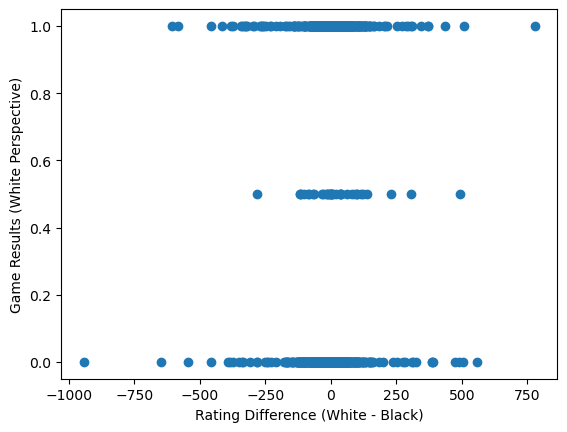

In [11]:
import matplotlib.pyplot as plt

plt.scatter(ratingDiff_W, results_W)
plt.xlabel("Rating Difference (White - Black)")
plt.ylabel("Game Results (White Perspective)")
plt.show()

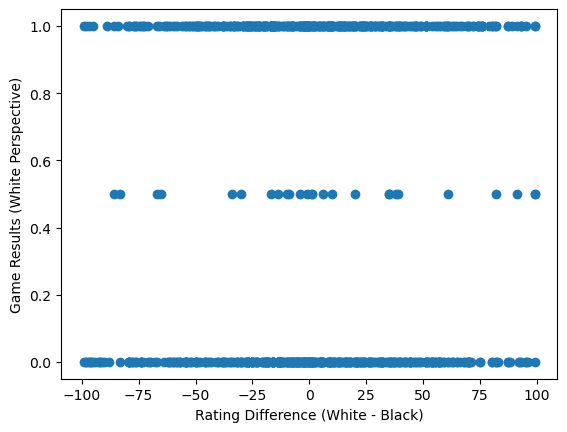

In [28]:
# Restrict the rating difference to -maxRatingDiff to maxRatingDiff
maxRatingDiff = 100
filter = np.abs(ratingDiff_W) < maxRatingDiff
ratingDiff_W_filtered = ratingDiff_W[filter]
results_W_filtered = results_W[filter]
plt.scatter(ratingDiff_W_filtered, results_W_filtered)
plt.xlabel("Rating Difference (White - Black)")
plt.ylabel("Game Results (White Perspective)")
plt.show()

In [26]:
# Group games into buckets based on rating difference
bucket_size = 5

# Bucket index (…, -2, -1, 0, 1, 2, …)
bucket = np.floor_divide(ratingDiff_W_filtered, bucket_size)

unique_buckets = np.unique(bucket)

bucket_centers = []
expected_score = []

for b in unique_buckets:
    mask = bucket == b
    bucket_centers.append((b + 0.5) * bucket_size)
    expected_score.append(results_W_filtered[mask].mean())

bucket_centers = np.array(bucket_centers)
expected_score = np.array(expected_score)

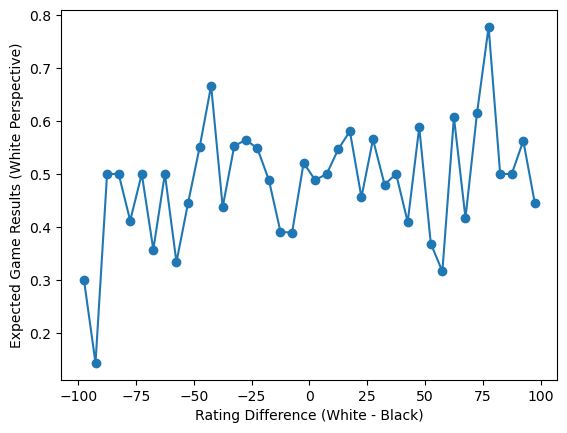

In [30]:
plt.plot(bucket_centers, expected_score, marker="o")
plt.xlabel("Rating Difference (White - Black)")
plt.ylabel("Expected Game Results (White Perspective)")
plt.show()

In [33]:
# Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(bucket_centers.reshape(-1, 1), expected_score)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.483
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[365.03]


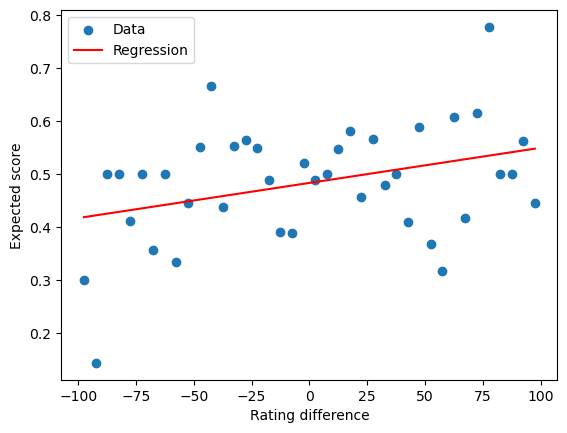

In [35]:
y_pred = model.predict(bucket_centers.reshape(-1, 1))

plt.scatter(bucket_centers, expected_score, label="Data")
plt.plot(bucket_centers, y_pred, label="Regression", color="red")
plt.xlabel("Rating difference")
plt.ylabel("Expected score")
plt.legend()
plt.show()